In [15]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

In [12]:
PATIENT_ID = "ID1"
ROOT = Path(r"D:\swec_derivatives_soft3") / PATIENT_ID
files = sorted(ROOT.glob("*_soft3.npz"))

print("Found seizure files:", len(files))
assert len(files) >= 2, "Need at least 2 seizures to do train/val split."

rng = np.random.default_rng(42)
files = np.array(files, dtype=object)
rng.shuffle(files)

val_frac = 0.2
n_val = max(1, int(len(files) * val_frac))
val_files = files[:n_val].tolist()
train_files = files[n_val:].tolist()

print("Train seizure files:", len(train_files))
print("Val seizure files:", len(val_files))
print("Val example:", Path(val_files[0]).name)

Found seizure files: 13
Train seizure files: 11
Val seizure files: 2
Val example: ID1_Sz10_soft3.npz


In [13]:
class Hard3NPZDataset(Dataset):
    """
    Returns:
      x: (C,T) float32
      y: int64 in {0,1,2} from y_hard if present else argmax(y_soft)
      meta: dict with t_sec, file, start_sec, end_sec
    """
    def __init__(self, npz_files):
        self.files = list(npz_files)
        self.refs = []
        self.cache = {}

        for fp in self.files:
            z = np.load(fp, allow_pickle=True)
            n = z["X"].shape[0]
            for i in range(n):
                self.refs.append((str(fp), i))

    def __len__(self):
        return len(self.refs)

    def _load(self, fp):
        if fp in self.cache:
            return self.cache[fp]

        z = np.load(fp, allow_pickle=True)
        fs = float(np.asarray(z["fs"]).item())
        start_sec = float(np.asarray(z["start_idx"]).item() / fs)
        end_sec   = float(np.asarray(z["end_idx"]).item() / fs)

        X = z["X"].astype(np.float32)
        if "y_hard" in z.files:
            y_hard = z["y_hard"].astype(np.int64)
        else:
            y_hard = z["y_soft"].astype(np.float32).argmax(axis=1).astype(np.int64)

        self.cache[fp] = {
            "X": X,
            "y": y_hard,
            "t0": z["t0"].astype(np.int64),
            "fs": fs,
            "start_sec": start_sec,
            "end_sec": end_sec,
            "file": fp,
        }
        return self.cache[fp]

    def __getitem__(self, idx):
        fp, i = self.refs[idx]
        d = self._load(fp)

        x = d["X"][i]              # (C,T)
        y = int(d["y"][i])         # 0/1/2
        t_sec = float(d["t0"][i] / d["fs"])

        meta = {
            "t_sec": t_sec,
            "file": d["file"],
            "start_sec": d["start_sec"],
            "end_sec": d["end_sec"],
        }
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long), meta

ds_tr = Hard3NPZDataset(train_files)
ds_va = Hard3NPZDataset(val_files)

print("Train windows:", len(ds_tr))
print("Val windows:", len(ds_va))

x0, y0, m0 = ds_tr[0]
n_ch, T = x0.shape
print("Example:", "C=", n_ch, "T=", T, "label=", y0.item(), "file=", Path(m0["file"]).name)

Train windows: 801
Val windows: 75
Example: C= 47 T= 5120 label= 0 file= ID1_Sz4_soft3.npz


In [16]:
# collect training labels
y_tr = np.array([ds_tr[i][1].item() for i in range(len(ds_tr))], dtype=np.int64)
counts = np.bincount(y_tr, minlength=3).astype(np.float32)
counts[counts == 0] = 1.0

# class weights: inverse frequency (normalized)
class_weights = counts.sum() / counts
class_weights = class_weights / class_weights.mean()
print("Train class counts [pre,ictal,post]:", counts.astype(int).tolist())
print("Class weights:", class_weights.tolist())

sample_weights = class_weights[y_tr]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(ds_tr, batch_size=64, sampler=sampler, num_workers=0)
val_loader   = DataLoader(ds_va, batch_size=128, shuffle=False, num_workers=0)

Train class counts [pre,ictal,post]: [198, 405, 198]
Class weights: [1.2053570747375488, 0.589285671710968, 1.2053570747375488]


In [17]:
class ChannelAttentionPool(nn.Module):
    """
    Input:  z (B,C,F,T')
    Output: pooled (B,F,T')
    """
    def __init__(self, F, hidden=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(F, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, z):
        # z: (B,C,F,T')
        g = z.mean(dim=-1)                 # (B,C,F)
        a = self.mlp(g).squeeze(-1)        # (B,C)
        w = torch.softmax(a, dim=1)        # (B,C)
        return (z * w[:, :, None, None]).sum(dim=1)  # (B,F,T')

class LiteCNN_Attn3(nn.Module):
    def __init__(self, n_ch, base=16, dropout=0.3):
        super().__init__()
        self.n_ch = n_ch
        self.base = base

        self.dw1 = nn.Conv1d(n_ch, n_ch*base, kernel_size=11, stride=2, padding=5, groups=n_ch)
        self.bn1 = nn.BatchNorm1d(n_ch*base)

        self.dw2 = nn.Conv1d(n_ch*base, n_ch*base, kernel_size=9, stride=2, padding=4, groups=n_ch)
        self.bn2 = nn.BatchNorm1d(n_ch*base)

        self.dw3 = nn.Conv1d(n_ch*base, n_ch*base, kernel_size=7, stride=2, padding=3, groups=n_ch)
        self.bn3 = nn.BatchNorm1d(n_ch*base)

        self.drop = nn.Dropout(dropout)
        self.attn = ChannelAttentionPool(F=base, hidden=64)

        self.fc1 = nn.Linear(base, 64)
        self.fc2 = nn.Linear(64, 3)

    def forward(self, x):
        # x: (B,C,T)
        z = self.drop(F.relu(self.bn1(self.dw1(x))))
        z = self.drop(F.relu(self.bn2(self.dw2(z))))
        z = self.drop(F.relu(self.bn3(self.dw3(z))))  # (B,C*base,T')

        B, _, Tp = z.shape
        z = z.view(B, self.n_ch, self.base, Tp)       # (B,C,base,T')

        z = self.attn(z)                              # (B,base,T')
        z = z.mean(dim=-1)                            # GAP over time -> (B,base)

        z = F.relu(self.fc1(z))
        logits = self.fc2(z)
        return logits

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = LiteCNN_Attn3(n_ch=n_ch, base=16, dropout=0.3).to(device)

# CrossEntropy with class weights
w = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=w)

opt = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4)

def eval_val_loss(model):
    model.eval()
    loss_sum, n = 0.0, 0
    with torch.no_grad():
        for xb, yb, _ in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss_sum += float(loss.item()) * xb.size(0)
            n += xb.size(0)
    return loss_sum / max(n, 1)

best = float("inf")
best_path = "litecnn_attn_soft3_id1_best.pt"
patience = 10
bad = 0
EPOCHS = 120  # you can increase safely because we early-stop

for ep in range(1, EPOCHS + 1):
    model.train()
    for xb, yb, _ in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

    vloss = eval_val_loss(model)
    scheduler.step(vloss)

    lr_now = opt.param_groups[0]["lr"]
    print(f"Epoch {ep:03d} | val CE={vloss:.4f} | lr={lr_now:.2e}")

    if vloss < best - 1e-4:
        best = vloss
        bad = 0
        torch.save(model.state_dict(), best_path)
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping.")
            break

print("Best val CE:", best, "| saved:", best_path)

Device: cuda
Epoch 001 | val CE=1.0664 | lr=5.00e-04
Epoch 002 | val CE=1.0193 | lr=5.00e-04
Epoch 003 | val CE=0.9785 | lr=5.00e-04
Epoch 004 | val CE=0.9405 | lr=5.00e-04
Epoch 005 | val CE=0.9005 | lr=5.00e-04
Epoch 006 | val CE=0.8693 | lr=5.00e-04
Epoch 007 | val CE=0.8390 | lr=5.00e-04
Epoch 008 | val CE=0.8234 | lr=5.00e-04
Epoch 009 | val CE=0.8145 | lr=5.00e-04
Epoch 010 | val CE=0.8043 | lr=5.00e-04
Epoch 011 | val CE=0.8493 | lr=5.00e-04
Epoch 012 | val CE=0.8392 | lr=5.00e-04
Epoch 013 | val CE=0.9447 | lr=5.00e-04
Epoch 014 | val CE=0.8351 | lr=5.00e-04
Epoch 015 | val CE=0.9729 | lr=2.50e-04
Epoch 016 | val CE=0.8753 | lr=2.50e-04
Epoch 017 | val CE=0.8993 | lr=2.50e-04
Epoch 018 | val CE=1.0422 | lr=2.50e-04
Epoch 019 | val CE=1.0916 | lr=2.50e-04
Epoch 020 | val CE=1.0180 | lr=1.25e-04
Early stopping.
Best val CE: 0.8042565584182739 | saved: litecnn_attn_soft3_id1_best.pt


Val hard-label accuracy: 0.52
[[33  0  3]
 [ 1  1  1]
 [31  0  5]]


C:\Users\ajars\AppData\Local\Temp\ipykernel_21628\2805866633.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=de

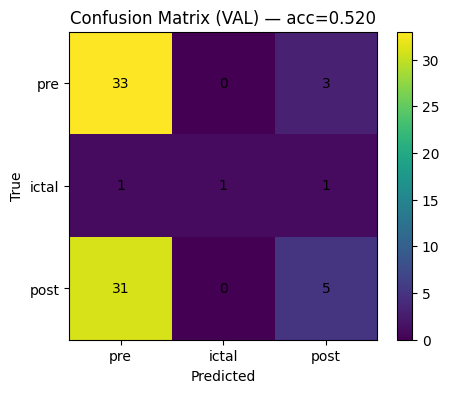

In [19]:
@torch.no_grad()
def eval_val_preds(model):
    model.eval()
    y_true, y_pred = [], []
    for xb, yb, _ in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        pred = logits.argmax(dim=1).cpu().numpy()
        y_true.append(yb.numpy())
        y_pred.append(pred)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    return y_true, y_pred

def confusion_matrix_3(y_true, y_pred):
    cm = np.zeros((3,3), dtype=np.int64)
    for yt, yp in zip(y_true, y_pred):
        cm[int(yt), int(yp)] += 1
    return cm

# load best
model.load_state_dict(torch.load(best_path, map_location=device))

y_true, y_pred = eval_val_preds(model)
cm = confusion_matrix_3(y_true, y_pred)
acc = np.trace(cm) / cm.sum()

print("Val hard-label accuracy:", acc)
print(cm)

labels = ["pre", "ictal", "post"]
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.xticks(range(3), labels)
plt.yticks(range(3), labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (VAL) — acc={acc:.3f}")
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i,j]), ha="center", va="center")
plt.colorbar()
plt.show()

In [20]:
@torch.no_grad()
def predict_one_file_probs(model, npz_path):
    z = np.load(npz_path, allow_pickle=True)
    X = z["X"].astype(np.float32)         # (N,C,T)
    t0 = z["t0"].astype(np.int64)
    fs = float(np.asarray(z["fs"]).item())
    start_sec = float(np.asarray(z["start_idx"]).item() / fs)
    end_sec   = float(np.asarray(z["end_idx"]).item() / fs)

    t_sec = t0 / fs

    model.eval()
    device = next(model.parameters()).device
    probs = []
    bs = 256
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i+bs]).to(device)
        logits = model(xb)
        p = torch.softmax(logits, dim=1).cpu().numpy()
        probs.append(p)
    probs = np.concatenate(probs, axis=0)

    order = np.argsort(t_sec)
    return t_sec[order], probs[order], start_sec, end_sec

val_npz = Path(val_files[0])
print("Plotting:", val_npz.name)

t_sec, P, start_sec, end_sec = predict_one_file_probs(model, val_npz)

plt.figure(figsize=(12,4))
plt.plot(t_sec, P[:,0], label="P(pre)")
plt.plot(t_sec, P[:,1], label="P(ictal)")
plt.plot(t_sec, P[:,2], label="P(post)")
plt.axvline(start_sec, linestyle="--", label="start")
plt.axvline(end_sec, linestyle="--", label="end")
plt.ylim(-0.02, 1.05)
plt.xlabel("Time (s)")
plt.ylabel("Probability")
plt.title(f"Phase probabilities vs time (VAL) — {val_npz.name} (WIN=10s, CROSS=2s)")
plt.grid(True)
plt.legend()
plt.show()

AxisError: axis 1 is out of bounds for array of dimension 1